# Time-Aware Advanced Models

## Goal
This notebook extends the existing modeling work using **one split only**: a strict **time-aware holdout**.

Main goals:
1. Build **Feature Set A** = full cleaned numeric set
2. Build **Feature Set B** = correlation-pruned set
3. Build **Feature Set C** = VIF-pruned + manually reduced interpretable set
4. Compare Ridge / Lasso / HistGradientBoosting / RandomForest / ExtraTrees / MLP on the same time-aware split
5. Save run logs, split metadata, plots, and worst-case tables for reporting

In [1]:
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

sys.path.append(str(PROJECT_ROOT / "src"))

REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.feature_engineering import (
    build_feature_sets_abc,
    compute_correlation_matrix,
    compute_vif_table,
    save_feature_sets_json,
)
from modeling.advanced_models import get_timeaware_model_registry, get_hgbr_sweep
from modeling.experiment_runner import (
    run_time_experiment,
    save_time_split_metadata,
    top_n_worst_predictions,
    grouped_mae,
)

TARGET = "life_expectancy_final"
YEAR_COL = "year"
TEST_YEARS = 3
RUN_LOG = REPORT_TABLES / "week10_week11_run_log.csv"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## Load processed data
This notebook works off the processed merged dataset. 

In [3]:
data_candidates = [
    PROJECT_ROOT / "data" / "processed" / "main_dataset.csv",
    PROJECT_ROOT / "data" / "processed" / "panel_dataset.csv",
]

DATA_PATH = None
for p in data_candidates:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find processed dataset. Expected one of:\n"
        + "\n".join(str(p) for p in data_candidates)
    )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print(df.shape)
df.head()

Loaded: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed/main_dataset.csv
(2265, 36)


,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,sanitation,injuries,communicable,noncommunicable_disease,life_expectancy_final
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,100,...,21.5,5949.999809,10.105348,3.25580,11.127,NaN,3673696.62,6528888.62,6988545.28,64.1885
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,100,...,20.7,4880.000114,9.528871,3.69522,11.142,NaN,3267937.78,6649335.87,6900348.40,61.4330
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,100,...,20.7,5989.999771,8.805941,3.45446,11.193,NaN,2807904.86,6813189.19,6799914.37,61.2125
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,100,...,21.1,8079.999924,7.897176,3.32000,11.341,NaN,2715550.23,7036448.02,6640268.93,60.7770
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,100,...,20.2,8930.000305,8.561907,3.46201,11.054,NaN,2540038.63,7181018.86,6539124.12,60.3765


## Build Feature Sets A, B, C
- **A**: full cleaned numeric set
- **B**: correlation-pruned
- **C**: VIF-pruned + manually reduced interpretable set

In [4]:
model_df, feature_sets, feature_meta = build_feature_sets_abc(
    df,
    target_col=TARGET,
    year_col=YEAR_COL,
    corr_threshold=0.90,
    vif_threshold=10.0,
)

feature_sets

/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encount

{'A': ['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'under_five_deaths',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'gdp',
  'population',
  'thinness_1_19_years',
  'thinness_5_9_years',
  'income_composition_of_resources',
  'schooling',
  'undernourishment',
  'co2',
  'health_expenditure_percent',
  'education_expenditure_percent',
  'unemployment',
  'sanitation',
  'injuries',
  'communicable',
  'noncommunicable_disease',
  'status_flag',
  'gdp_log1p',
  'population_log1p',
  'co2_log1p',
  'gdp_missing_flag',
  'schooling_missing_flag',
  'sanitation_missing_flag',
  'adult_mortality_missing_flag',
  'schooling__x__status_flag',
  'gdp_log1p__x__status_flag'],
 'B': ['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'population',

In [5]:
save_feature_sets_json(
    feature_sets,
    feature_meta,
    REPORT_TABLES / "feature_sets.json",
)

with open(REPORT_TABLES / "feature_sets.json", "r", encoding="utf-8") as f:
    preview = json.load(f)

preview.keys()

dict_keys(['feature_sets', 'meta'])

In [6]:
pd.DataFrame(
    {
        "feature_set": ["A", "B", "C"],
        "n_features": [len(feature_sets["A"]), len(feature_sets["B"]), len(feature_sets["C"])],
    }
)

,feature_set,n_features
0,A,38
1,B,31
2,C,5


## Correlation matrix
This is the main numeric basis for reducing Feature Set A into Feature Set B.

In [7]:
corr_a = compute_correlation_matrix(model_df, feature_sets["A"])
corr_b = compute_correlation_matrix(model_df, feature_sets["B"])

corr_a.to_csv(REPORT_TABLES / "week10_corr_matrix_A.csv")
corr_b.to_csv(REPORT_TABLES / "week10_corr_matrix_B.csv")

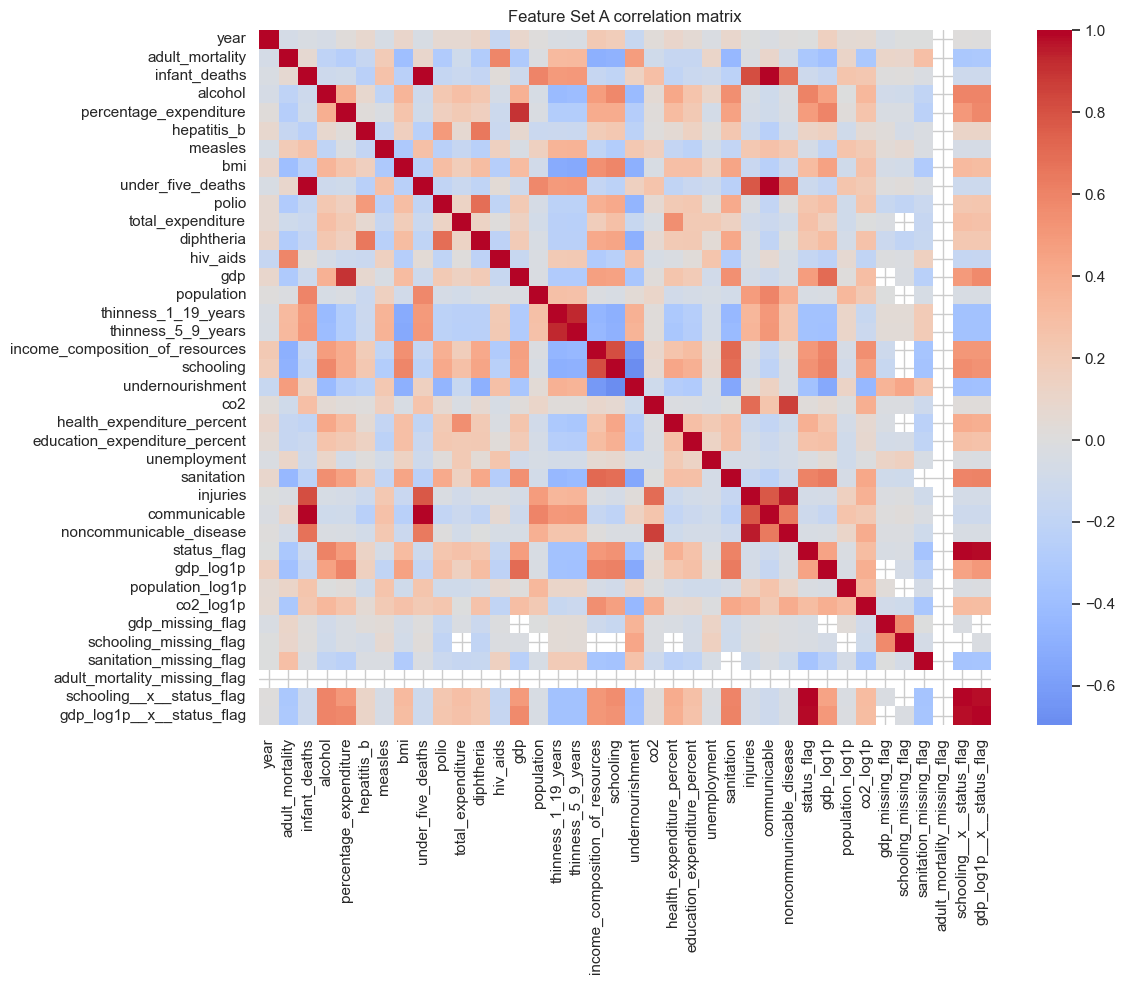

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_a, cmap="coolwarm", center=0)
plt.title("Feature Set A correlation matrix")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_corr_matrix_A.png", dpi=200, bbox_inches="tight")
plt.show()

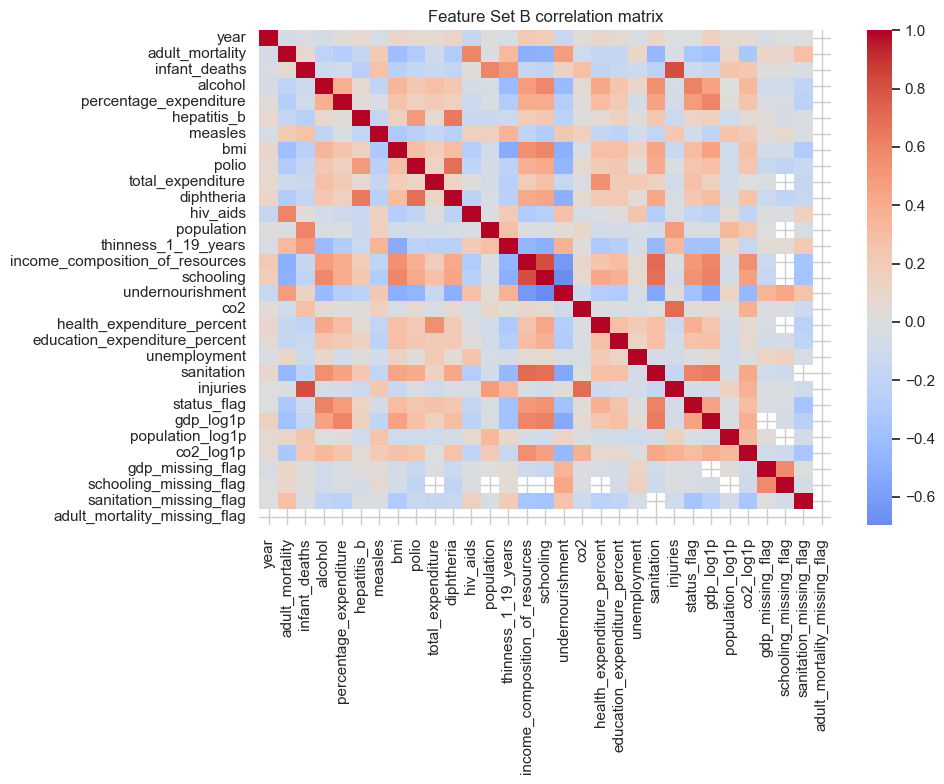

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_b, cmap="coolwarm", center=0)
plt.title("Feature Set B correlation matrix")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_corr_matrix_B.png", dpi=200, bbox_inches="tight")
plt.show()

## VIF check
This is the second reduction step used to move from the correlation-pruned set toward a smaller, more stable set.

In [10]:
vif_b = compute_vif_table(model_df, feature_sets["B"])
vif_c = compute_vif_table(model_df, feature_sets["C"])

vif_b.to_csv(REPORT_TABLES / "week10_vif_B.csv", index=False)
vif_c.to_csv(REPORT_TABLES / "week10_vif_C.csv", index=False)

display(vif_b.head(15))
display(vif_c)

/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,vif
0,year,135.983207
1,schooling,61.837763
2,co2_log1p,49.180665
3,population_log1p,45.149983
4,gdp_log1p,40.213728
5,income_composition_of_resources,39.291696
6,diphtheria,34.293036
7,polio,28.045180
8,hepatitis_b,20.203371
9,health_expenditure_percent,13.034822


,feature,vif
0,status_flag,1.646586
1,year,1.586456
2,percentage_expenditure,1.537446
3,hiv_aids,1.172295
4,infant_deaths,1.080799


## Freeze the time-aware split metadata
We use only the time-aware split in all experiments below and save the metadata once.

In [11]:
from modeling.advanced_models import get_timeaware_model_registry

# Run one tiny experiment just to capture split metadata
tmp_registry = get_timeaware_model_registry(random_state=RANDOM_STATE)
tmp_spec = tmp_registry["RidgeCV"]

tmp_row, tmp_pred, tmp_split_info, tmp_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="RidgeCV",
    model=tmp_spec["model"],
    scale_mode=tmp_spec["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=None,
    split_label="time_C",
)

save_time_split_metadata(
    tmp_split_info,
    REPORT_TABLES / "week10_time_split_metadata.json",
)

tmp_split_info

SplitInfo(split_type='time', n_train=1812, n_test=453, extra={'year_col': 'year', 'test_years': 3, 'max_year': 2015, 'cutoff': 2013})

## HistGradientBoosting sweep

In [12]:
hgb_sweep = get_hgbr_sweep(random_state=RANDOM_STATE)

hgb_rows = []
hgb_artifacts = {}

for feature_set_name in ["A", "B", "C"]:
    for model_name, spec in hgb_sweep.items():
        row, pred_df, split_info, pipe = run_time_experiment(
            df=model_df,
            feature_list=feature_sets[feature_set_name],
            target_col=TARGET,
            year_col=YEAR_COL,
            model_name=model_name,
            model=spec["model"],
            scale_mode=spec["scale_mode"],
            test_years=TEST_YEARS,
            run_log_path=RUN_LOG,
            split_label=f"time_{feature_set_name}",
        )
        row["feature_set"] = feature_set_name
        row["family"] = "HistGBR"
        hgb_rows.append(row)
        hgb_artifacts[(feature_set_name, model_name)] = {
            "pred_df": pred_df,
            "pipe": pipe,
            "split_info": split_info,
        }

hgb_results = pd.DataFrame(hgb_rows).sort_values(["feature_set", "rmse", "mae"])
hgb_results.to_csv(REPORT_TABLES / "week10_hgbr_sweep.csv", index=False)

In [13]:
best_hgb_by_set = (
    hgb_results.loc[
        hgb_results.groupby("feature_set")["rmse"].idxmin()
    ]
    .sort_values("rmse")
    .reset_index(drop=True)
)

best_hgb_by_set

,model_name,split_name,n_train,n_test,rmse,mae,r2,feature_set,family
0,HGB_lr0.05_d5_leaf31,time_B,1812,453,1.522629,1.036546,0.966918,B,HistGBR
1,HGB_lr0.05_d5_leaf31,time_A,1812,453,1.536980,1.033945,0.966291,A,HistGBR
2,HGB_lr0.05_dNone_leaf63,time_C,1812,453,3.539506,2.761731,0.821231,C,HistGBR


## Full model comparison on A, B, C
Now compare the best boosted-tree configuration against Ridge, Lasso, Random Forest, Extra Trees, and MLP.

In [14]:
registry = get_timeaware_model_registry(random_state=RANDOM_STATE)

# Replace default HistGBR with the best one per feature set when we run comparisons
comparison_rows = []
comparison_artifacts = {}

for feature_set_name in ["A", "B", "C"]:
    best_hgb_name = best_hgb_by_set.loc[
        best_hgb_by_set["feature_set"] == feature_set_name, "model_name"
    ].iloc[0]
    best_hgb_spec = hgb_sweep[best_hgb_name]

    local_registry = {
        "RidgeCV": registry["RidgeCV"],
        "LassoCV": registry["LassoCV"],
        "HistGBR_best": best_hgb_spec,
        "RandomForest": registry["RandomForest"],
        "ExtraTrees": registry["ExtraTrees"],
        "MLP": registry["MLP"],
    }

    for model_name, spec in local_registry.items():
        row, pred_df, split_info, pipe = run_time_experiment(
            df=model_df,
            feature_list=feature_sets[feature_set_name],
            target_col=TARGET,
            year_col=YEAR_COL,
            model_name=model_name,
            model=spec["model"],
            scale_mode=spec["scale_mode"],
            test_years=TEST_YEARS,
            run_log_path=RUN_LOG,
            split_label=f"time_{feature_set_name}",
        )
        row["feature_set"] = feature_set_name
        comparison_rows.append(row)
        comparison_artifacts[(feature_set_name, model_name)] = {
            "pred_df": pred_df,
            "pipe": pipe,
            "split_info": split_info,
        }

comparison_df = pd.DataFrame(comparison_rows).sort_values(["feature_set", "rmse", "mae"])
comparison_df.to_csv(REPORT_TABLES / "week10_model_comparison.csv", index=False)
comparison_df

,model_name,split_name,n_train,n_test,rmse,mae,r2,feature_set
4,ExtraTrees,time_A,1812,453,1.296964,0.909274,0.975997,A
2,HistGBR_best,time_A,1812,453,1.536980,1.033945,0.966291,A
3,RandomForest,time_A,1812,453,1.629146,1.114210,0.962127,A
1,LassoCV,time_A,1812,453,3.097857,2.471737,0.863060,A
0,RidgeCV,time_A,1812,453,3.168624,2.533057,0.856732,A
5,MLP,time_A,1812,453,3.271696,2.520767,0.847260,A
10,ExtraTrees,time_B,1812,453,1.329640,0.919251,0.974772,B
8,HistGBR_best,time_B,1812,453,1.522629,1.036546,0.966918,B
9,RandomForest,time_B,1812,453,1.636264,1.118167,0.961796,B
11,MLP,time_B,1812,453,2.916821,2.304887,0.878598,B


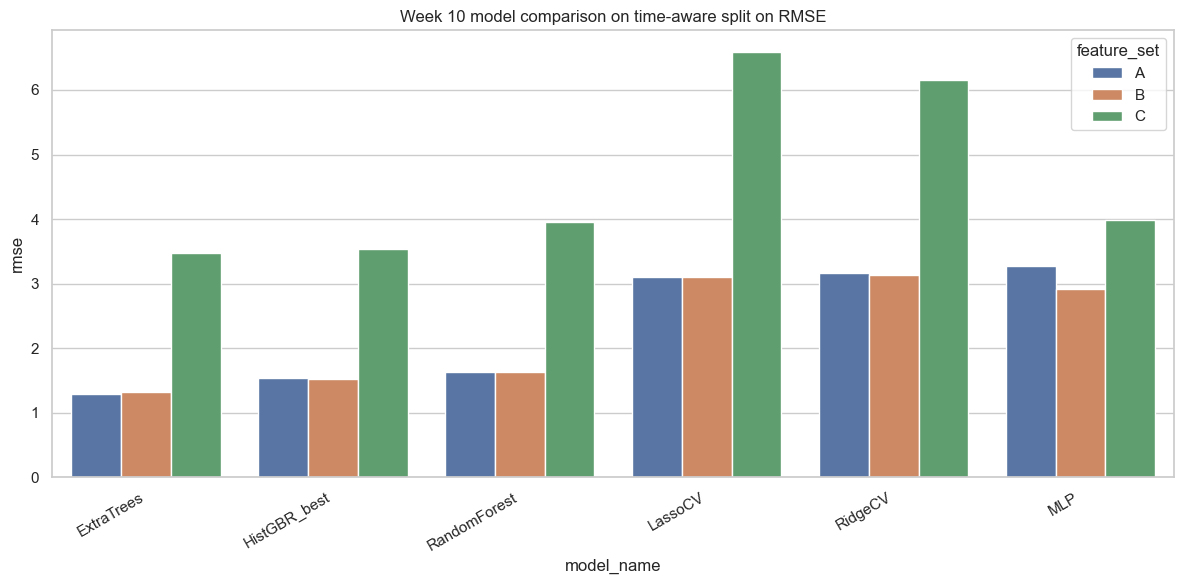

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="model_name", y="rmse", hue="feature_set")
plt.title("Week 10 model comparison on time-aware split on RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_model_comparison_rmse.png", dpi=200, bbox_inches="tight")
plt.show()

## Diagnostics for the best boosted model

These figures/tables support later reporting:
- predicted vs actual
- residuals vs predicted
- error histogram
- top 10 worst predictions
- MAE by region
- MAE by year

In [16]:
best_boosted_row = (
    comparison_df[comparison_df["model_name"] == "HistGBR_best"]
    .sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
    .iloc[0]
)

best_boosted_row

model_name     HistGBR_best
split_name           time_B
n_train                1812
n_test                  453
rmse               1.522629
mae                1.036546
r2                 0.966918
feature_set               B
Name: 8, dtype: object

In [17]:
best_fs = best_boosted_row["feature_set"]
best_pred_df = comparison_artifacts[(best_fs, "HistGBR_best")]["pred_df"]

worst10 = top_n_worst_predictions(best_pred_df, n=10)
mae_by_year = grouped_mae(best_pred_df, "year")

worst10.to_csv(REPORT_TABLES / "week10_best_boosted_worst10.csv", index=False)
mae_by_year.to_csv(REPORT_TABLES / "week10_best_boosted_mae_by_year.csv", index=False)

display(worst10)
display(mae_by_year.head(10))

,year,y_true,y_pred,error,abs_error
0,2015,51.970500,60.293805,8.323305,8.323305
1,2014,50.236000,58.271254,8.035254,8.035254
2,2013,65.049500,58.201306,-6.848194,6.848194
3,2015,59.909500,66.588117,6.678617,6.678617
4,2015,62.992500,67.858473,4.865973,4.865973
5,2015,55.460000,60.081533,4.621533,4.621533
6,2014,85.060976,80.504932,-4.556043,4.556043
7,2015,61.215500,65.687255,4.471755,4.471755
8,2014,54.064500,49.699932,-4.364568,4.364568
9,2015,59.861500,64.124666,4.263166,4.263166


,year,mae
0,2015,1.226567
1,2014,1.057464
2,2013,0.825608


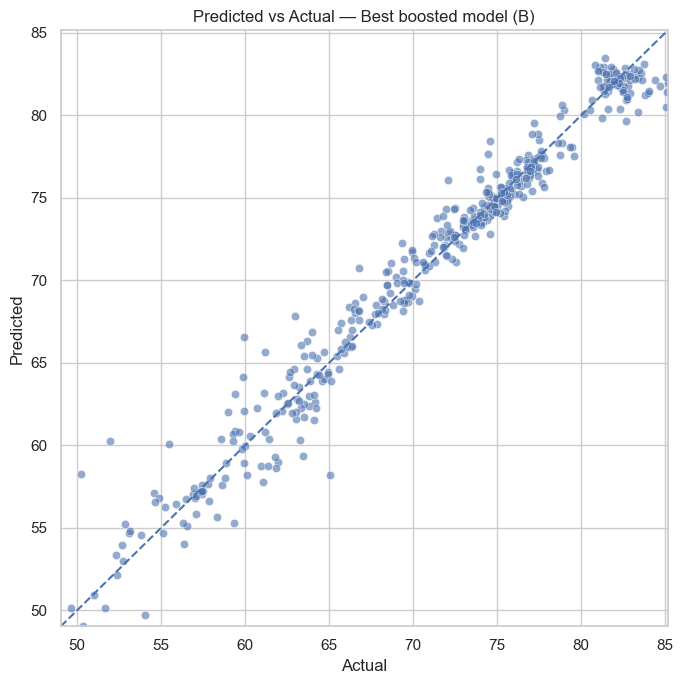

In [18]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_pred_df, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_pred_df["y_true"].min(), best_pred_df["y_pred"].min()),
    max(best_pred_df["y_true"].max(), best_pred_df["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — Best boosted model ({best_fs})")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_best_boosted_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

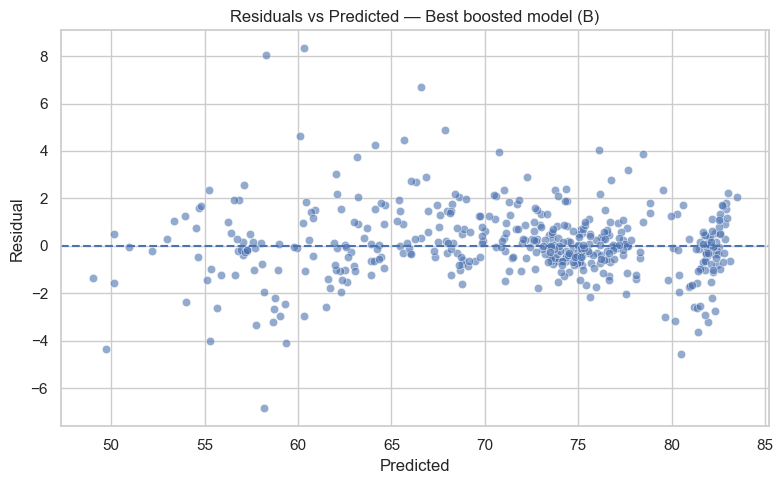

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=best_pred_df, x="y_pred", y="error", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted — Best boosted model ({best_fs})")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_best_boosted_residuals_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

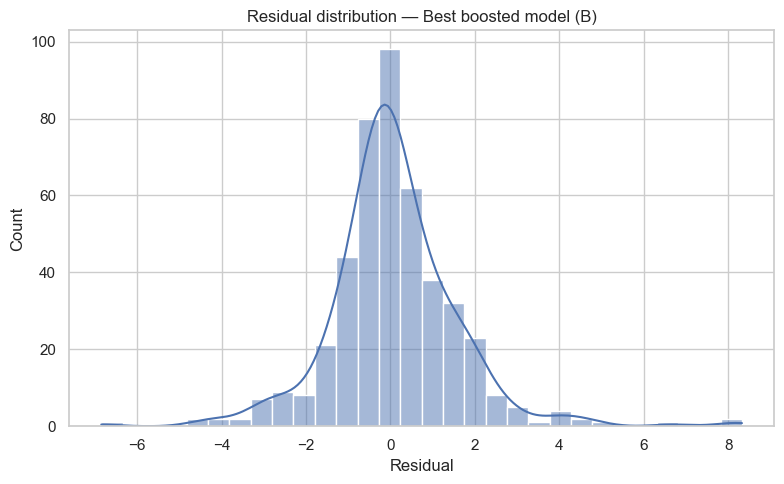

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(best_pred_df["error"], bins=30, kde=True)
plt.xlabel("Residual")
plt.title(f"Residual distribution — Best boosted model ({best_fs})")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_best_boosted_residual_hist.png", dpi=200, bbox_inches="tight")
plt.show()